## 1. Imports


In [3]:
import pandas as pd
import numpy as np
import implicit
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

## 2. Carregamento dos Dados

In [4]:
ratings = pd.read_csv('../Mini_trabalho_5/dados_processados/ratings_processado.csv')
print(ratings.shape)
print(ratings.head())

(90274, 6)
   userId  movieId  rating  timestamp  rating_norm  rating_scaled
0       1        1     4.0  964982703    -0.361233       0.484795
1       1        3     4.0  964981247    -0.361233       0.484795
2       1        6     4.0  964982224    -0.361233       0.484795
3       1       47     5.0  964983815     0.638767       0.617611
4       1       50     5.0  964982931     0.638767       0.617611


## 3. Divisão Treino e Teste


In [5]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)
print(f'Treino: {len(train)}')
print(f'Teste: {len(test)}')

Treino: 72219
Teste: 18055


## 4. Baseline

In [6]:
media_global = train['rating'].mean()
test['pred_baseline'] = media_global
rmse_baseline = np.sqrt(mean_squared_error(test['rating'], test['pred_baseline']))
print(f'RMSE Baseline: {rmse_baseline:.4f}')

RMSE Baseline: 1.0275


## 5. SVD


In [7]:
# Monta a matriz usuário-filme
matriz = train.pivot_table(index='userId', columns='movieId', values='rating').fillna(media_global)

# Aplica SVD
svd = TruncatedSVD(n_components=50, random_state=42)
matriz_reduzida = svd.fit_transform(matriz)
matriz_reconstruida = svd.inverse_transform(matriz_reduzida)

df_reconstruida = pd.DataFrame(matriz_reconstruida, index=matriz.index, columns=matriz.columns)

print(f'Matriz original:     {matriz.shape}')
print(f'Matriz reconstruída: {df_reconstruida.shape}')

Matriz original:     (610, 3650)
Matriz reconstruída: (610, 3650)


In [8]:
preds_svd = []
for _, row in test.iterrows():
    user = row['userId']
    movie = row['movieId']
    
    if user in df_reconstruida.index and movie in df_reconstruida.columns:
        pred = df_reconstruida.loc[user, movie]
    else:
        pred = media_global
        
    preds_svd.append(pred)
    
test['pred_svd'] = preds_svd
rmse_svd = np.sqrt(mean_squared_error(test['rating'], test['pred_svd']))
print(f'RMSE SVD: {rmse_svd:.4f}')

RMSE SVD: 0.9886


## 6. Modelo KNN

In [9]:
knn = NearestNeighbors(n_neighbors=10, metric = 'cosine')
knn.fit(matriz)

preds_knn = []

for _,row in test.iterrows():
    user = row['userId']
    movie = row['movieId']
    
    if user in matriz.index and movie in matriz.columns:
        user_idx = matriz.index.get_loc(user)
        distances, indices = knn.kneighbors([matriz.iloc[user_idx]])
        vizinhos = matriz.iloc[indices[0]]
        notas_vizinhos = vizinhos[movie]
        notas_validas = notas_vizinhos[notas_vizinhos != media_global]
        pred = notas_validas.mean() if len(notas_validas) > 0 else media_global
    else:
        pred = media_global
        
    preds_knn.append(pred)
    
test['pred_knn'] = preds_knn
rmse_knn = np.sqrt(mean_squared_error(test['rating'], test['pred_knn']))
print(f'RMSE KNN: {rmse_knn:.4f}')

RMSE KNN: 1.0262


## 7. Comparação de Modelos

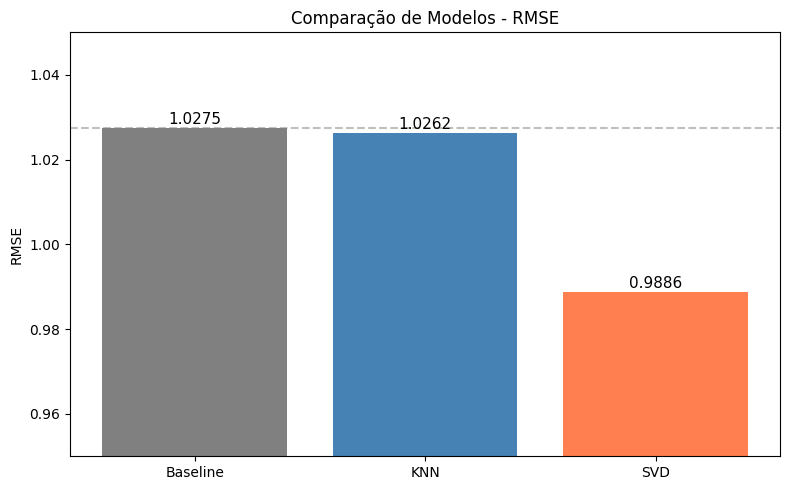

In [11]:
modelos = ['Baseline', 'KNN', 'SVD']
rmses = [rmse_baseline, rmse_knn, rmse_svd]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, rmses, color=['gray', 'steelblue', 'coral'])
plt.axhline(rmse_baseline, color = 'gray', linestyle = '--', alpha =0.5)
plt.title('Comparação de Modelos - RMSE')
plt.ylabel('RMSE')
plt.ylim(0.95, 1.05)

for bar, rmse in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{rmse:.4f}', ha='center', fontsize = 11)
    
plt.tight_layout()
plt.savefig('assets/comparacao_modelos.png')
plt.show()

## 8. Conclusão

Foram testados três modelos para o problema de recomendação de filmes, avaliados pela métrica RMSE — quanto menor, melhor.

O **Baseline** serviu como referência mínima, prevendo a média global para todas as avaliações e obtendo RMSE de 1.0275.

O **KNN** tentou capturar similaridade entre usuários para fazer previsões, obtendo RMSE de 1.0262 — uma melhora mínima em relação ao Baseline, praticamente irrelevante dado o alto nível de esparsidade dos dados.

O **SVD** apresentou o melhor desempenho com RMSE de 0.9886, sendo o único modelo que superou o Baseline de forma significativa. Isso era esperado, já que a fatoração de matrizes é uma técnica consagrada para sistemas de recomendação e lida bem com dados esparsos.

O SVD é portanto o modelo mais promissor para as próximas etapas do projeto.